naive bayes types comparison
-----------------------------------
gaussian nb -> 1.0
multinomial nb -> 0.972
bernoulli nb -> 0.306


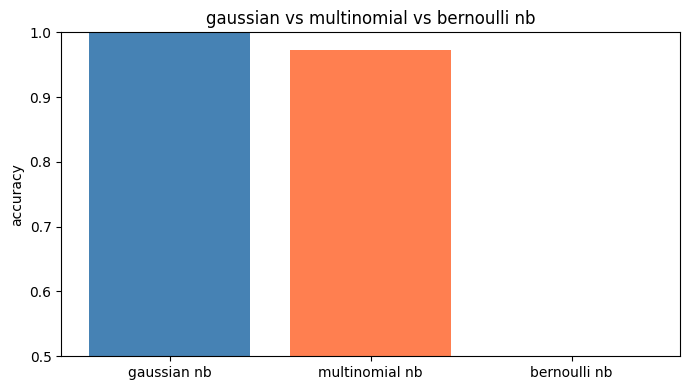

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

wine = load_wine()
x = wine.data
y = wine.target

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

models = {
    "gaussian nb":     GaussianNB(),
    "multinomial nb":  MultinomialNB(),
    "bernoulli nb":    BernoulliNB()
}

print("naive bayes types comparison")
print("-" * 35)

scores = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    score = round(accuracy_score(y_test, model.predict(x_test)), 3)
    scores[name] = score
    print(name, "->", score)

plt.figure(figsize=(7, 4))
plt.bar(scores.keys(), scores.values(),
        color=["steelblue", "coral", "green"])
plt.title("gaussian vs multinomial vs bernoulli nb")
plt.ylabel("accuracy")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()